# 🏠 California Housing Price Prediction
## Complete Regression Benchmark — Classical ML + Deep Learning (ANN)

> **Dataset :** California Housing (sklearn / Kaggle) — 20,640 samples · 9 features  
> **Target :** `median_house_value` (USD)  
> **Models :** Linear · Ridge · Lasso · ElasticNet · Decision Tree · Random Forest · SVR · KNN · Gradient Boosting · XGBoost · ANN (PyTorch)  
> **Metrics :** MAE · MSE · RMSE · R² · Training Time · Prediction Time  

---


## 1. 📦 Imports & Global Configuration

In [1]:
import warnings; warnings.filterwarnings('ignore')

# ── Core ──────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import time, pickle, tracemalloc, os

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.patches import FancyBboxPatch

# ── Scikit-learn ──────────────────────────────────────────────────────────────
from sklearn.model_selection   import train_test_split, cross_val_score
from sklearn.preprocessing     import StandardScaler
from sklearn.metrics           import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model      import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree              import DecisionTreeRegressor
from sklearn.ensemble          import (RandomForestRegressor,
                                        GradientBoostingRegressor,
                                        AdaBoostRegressor)
from sklearn.svm               import SVR
from sklearn.neighbors         import KNeighborsRegressor
from xgboost                   import XGBRegressor

# ── PyTorch ───────────────────────────────────────────────────────────────────
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# ── Display ───────────────────────────────────────────────────────────────────
from IPython.display import display
pd.set_option('display.float_format', '{:.2f}'.format)

# ── Plot theme ────────────────────────────────────────────────────────────────
DARK_BG  = '#0d1117'
CARD_BG  = '#161b22'
ACCENT   = '#58a6ff'
GREEN    = '#3fb950'
RED      = '#f85149'
YELLOW   = '#d29922'
PURPLE   = '#bc8cff'
PALETTE  = ['#58a6ff','#3fb950','#f85149','#d29922','#bc8cff',
            '#ff7b72','#79c0ff','#56d364','#ffa657','#d2a8ff','#ff6e96']

plt.rcParams.update({
    'figure.facecolor' : DARK_BG,  'axes.facecolor'  : CARD_BG,
    'axes.edgecolor'   : '#30363d','axes.labelcolor' : '#e6edf3',
    'xtick.color'      : '#8b949e','ytick.color'     : '#8b949e',
    'text.color'       : '#e6edf3','grid.color'      : '#21262d',
    'grid.linestyle'   : '--',     'grid.alpha'      : 0.6,
    'font.family'      : 'DejaVu Sans', 'font.size'  : 11,
    'axes.titlesize'   : 13,       'axes.titleweight': 'bold',
    'axes.titlepad'    : 12,
})

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("✅ All libraries loaded")
print(f"   PyTorch device : {DEVICE}")


✅ All libraries loaded
   PyTorch device : cpu


## 2. 📂 Load & Inspect Dataset

In [2]:
df = pd.read_csv('housing.csv')
print(f"Shape  : {df.shape}")
print(f"Memory : {df.memory_usage(deep=True).sum() / 1024:.1f} KB")
df.head()


Shape  : (20640, 10)
Memory : 2762.8 KB


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.00,880.00,129.00,322.00,126.00,8.33,452600.00,NEAR BAY
1,-122.22,37.86,21.00,7099.00,1106.00,2401.00,1138.00,8.30,358500.00,NEAR BAY
2,-122.24,37.85,52.00,1467.00,190.00,496.00,177.00,7.26,352100.00,NEAR BAY
3,-122.25,37.85,52.00,1274.00,235.00,558.00,219.00,5.64,341300.00,NEAR BAY
4,-122.25,37.85,52.00,1627.00,280.00,565.00,259.00,3.85,342200.00,NEAR BAY


In [3]:
print("━" * 55)
print("  COLUMN INFO")
print("━" * 55)
df.info()


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  COLUMN INFO
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [4]:
print("STATISTICAL SUMMARY")
df.describe().round(2)


STATISTICAL SUMMARY


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.00,20640.00,20640.00,20640.00,20433.00,20640.00,20640.00,20640.00,20640.00
mean,-119.57,35.63,28.64,2635.76,537.87,1425.48,499.54,3.87,206855.82
std,2.00,2.14,12.59,2181.62,421.39,1132.46,382.33,1.90,115395.62
min,-124.35,32.54,1.00,2.00,1.00,3.00,1.00,0.50,14999.00
25%,-121.80,33.93,18.00,1447.75,296.00,787.00,280.00,2.56,119600.00
50%,-118.49,34.26,29.00,2127.00,435.00,1166.00,409.00,3.53,179700.00
75%,-118.01,37.71,37.00,3148.00,647.00,1725.00,605.00,4.74,264725.00
max,-114.31,41.95,52.00,39320.00,6445.00,35682.00,6082.00,15.00,500001.00


## 3. 🔍 Exploratory Data Analysis

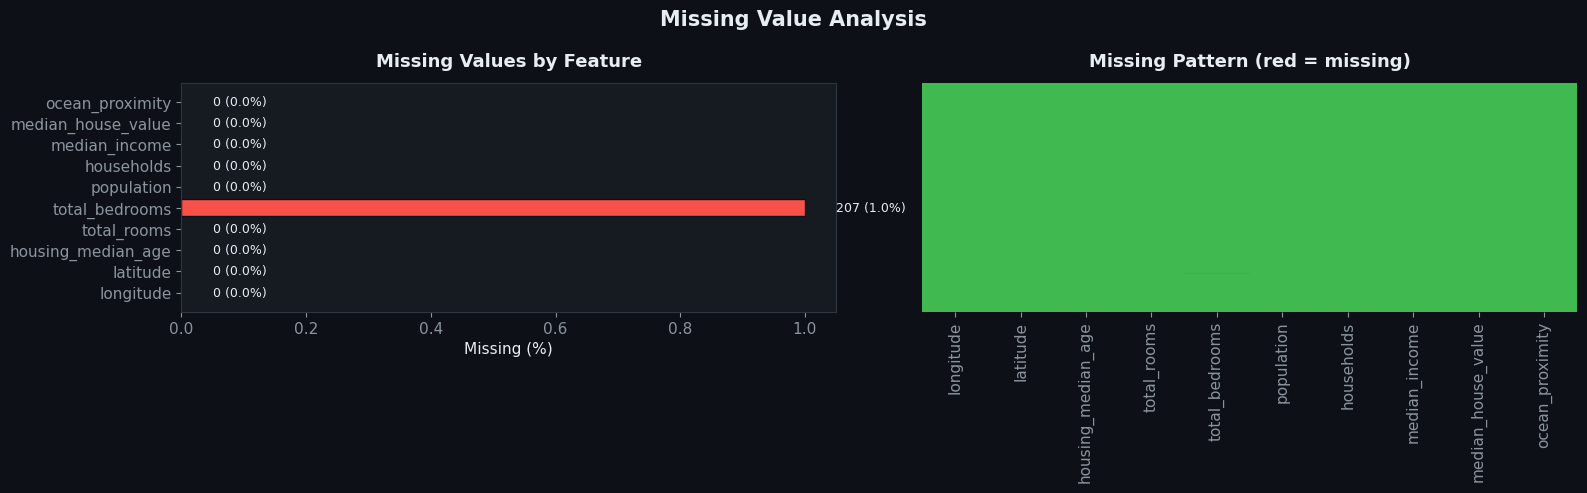

Columns with missing values: ['total_bedrooms']


In [5]:
# ── 3.1  Missing values heatmap ───────────────────────────────────────────────
missing = df.isnull().sum().reset_index()
missing.columns = ['Feature', 'Missing']
missing['Pct'] = (missing['Missing'] / len(df) * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Missing Value Analysis', fontsize=15, fontweight='bold')

# Bar chart
colors = [RED if v > 0 else GREEN for v in missing['Missing']]
axes[0].barh(missing['Feature'], missing['Pct'], color=colors, edgecolor='#0d1117')
axes[0].set_xlabel('Missing (%)')
axes[0].set_title('Missing Values by Feature')
for i, (val, pct) in enumerate(zip(missing['Missing'], missing['Pct'])):
    axes[0].text(pct + 0.05, i, f'{val} ({pct}%)', va='center', fontsize=9)

# Heatmap (boolean)
sns.heatmap(df.isnull(), yticklabels=False, cbar=False,
            cmap=['#3fb950','#f85149'], ax=axes[1])
axes[1].set_title('Missing Pattern (red = missing)')

plt.tight_layout()
plt.savefig('eda_missing.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()

missing_cols = missing[missing['Missing'] > 0]['Feature'].tolist()
print(f"Columns with missing values: {missing_cols}")


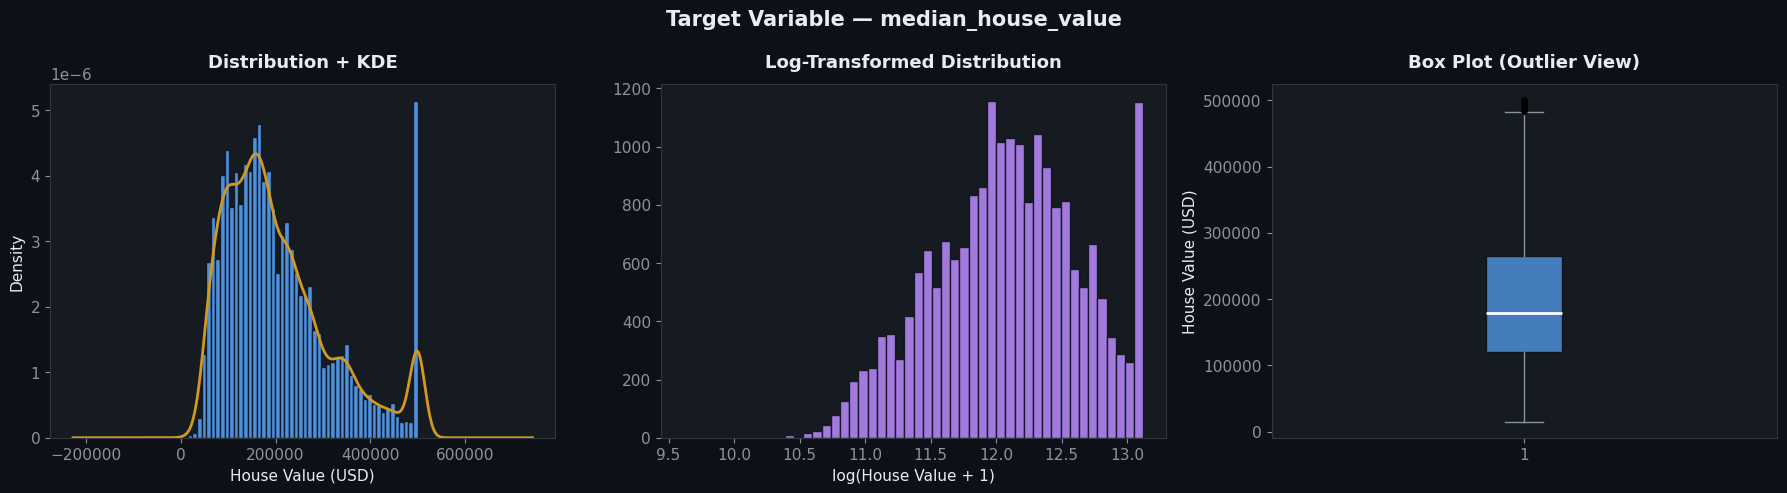

Skewness : 0.9778
Kurtosis : 0.3279
Mean     : $206,856
Median   : $179,700


In [6]:
# ── 3.2  Target distribution ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Target Variable — median_house_value', fontsize=15, fontweight='bold')

# Histogram + KDE
axes[0].hist(df['median_house_value'], bins=50, color=ACCENT,
             edgecolor=DARK_BG, alpha=0.85, density=True)
df['median_house_value'].plot.kde(ax=axes[0], color=YELLOW, linewidth=2)
axes[0].set_title('Distribution + KDE')
axes[0].set_xlabel('House Value (USD)')
axes[0].set_ylabel('Density')

# Log-transformed
axes[1].hist(np.log1p(df['median_house_value']), bins=50, color=PURPLE,
             edgecolor=DARK_BG, alpha=0.85)
axes[1].set_title('Log-Transformed Distribution')
axes[1].set_xlabel('log(House Value + 1)')

# Box plot
axes[2].boxplot(df['median_house_value'], patch_artist=True,
                boxprops=dict(facecolor=ACCENT, alpha=0.7),
                medianprops=dict(color='white', linewidth=2),
                whiskerprops=dict(color='#8b949e'),
                capprops=dict(color='#8b949e'),
                flierprops=dict(marker='o', color=RED, markersize=3, alpha=0.4))
axes[2].set_title('Box Plot (Outlier View)')
axes[2].set_ylabel('House Value (USD)')

plt.tight_layout()
plt.savefig('eda_target.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()

print(f"Skewness : {df['median_house_value'].skew():.4f}")
print(f"Kurtosis : {df['median_house_value'].kurt():.4f}")
print(f"Mean     : ${df['median_house_value'].mean():,.0f}")
print(f"Median   : ${df['median_house_value'].median():,.0f}")


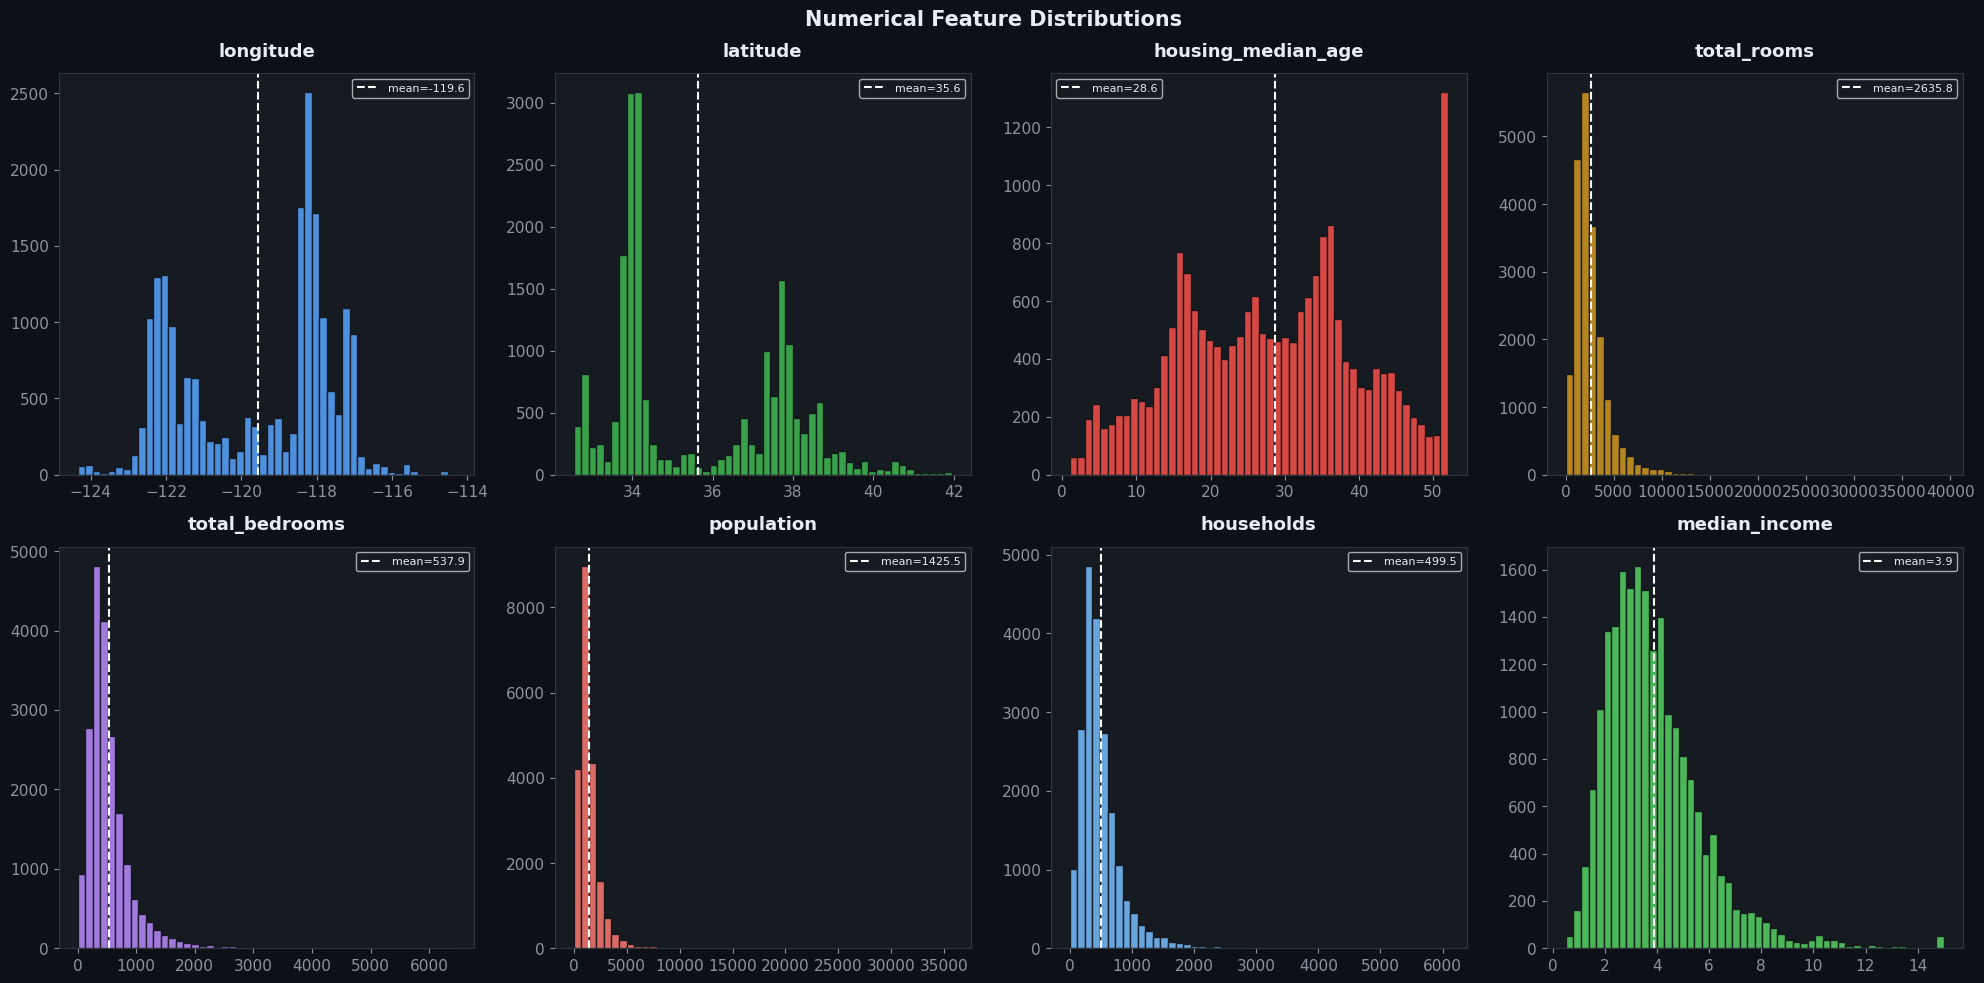

In [7]:
# ── 3.3  Numerical feature distributions ─────────────────────────────────────
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c != 'median_house_value']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Numerical Feature Distributions', fontsize=15, fontweight='bold')

for i, (ax, col) in enumerate(zip(axes.flat, num_cols)):
    color = PALETTE[i % len(PALETTE)]
    ax.hist(df[col], bins=50, color=color, edgecolor=DARK_BG, alpha=0.85)
    ax.set_title(col)
    ax.set_xlabel('')
    mean_val = df[col].mean()
    ax.axvline(mean_val, color='white', linestyle='--', linewidth=1.5, label=f'mean={mean_val:.1f}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()


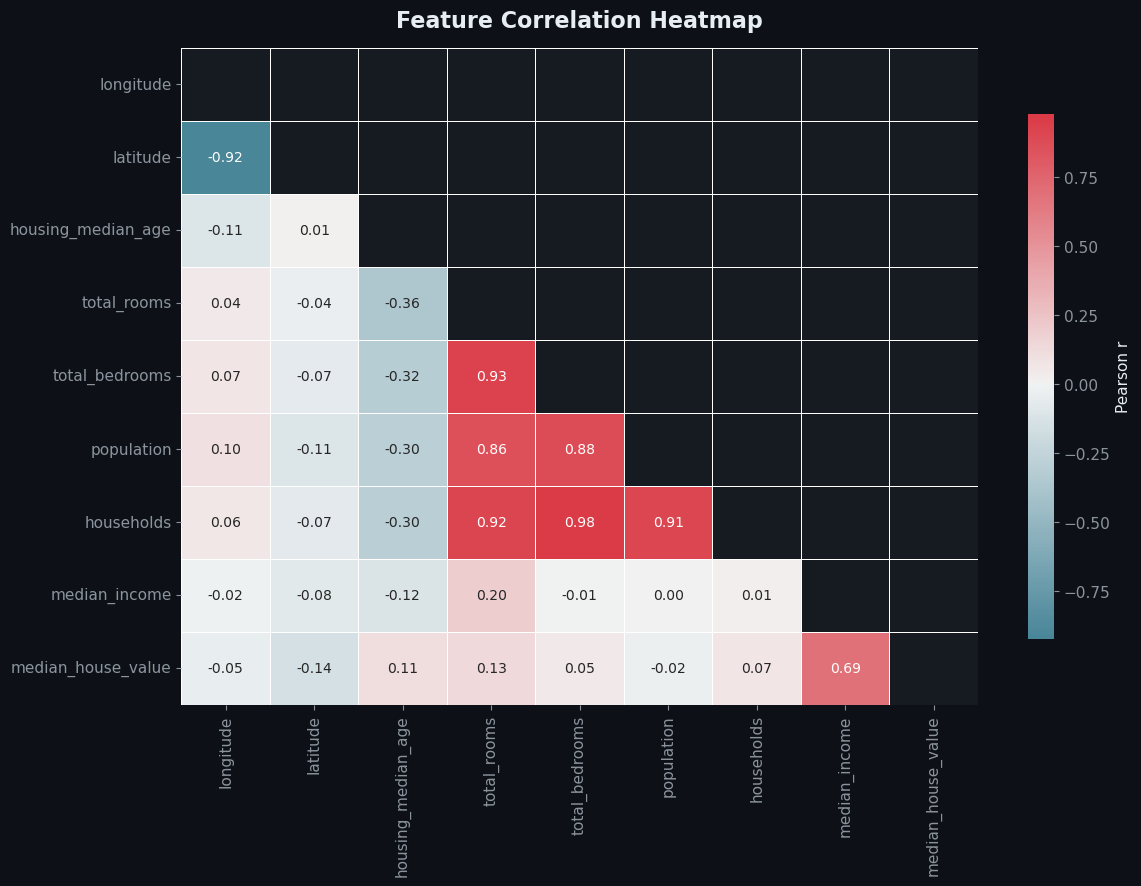

In [8]:
# ── 3.4  Correlation heatmap ──────────────────────────────────────────────────
corr = df.select_dtypes(include=np.number).corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, center=0, annot=True, fmt='.2f',
            linewidths=0.5, ax=ax, annot_kws={'size': 10},
            cbar_kws={'shrink': 0.8, 'label': 'Pearson r'})
ax.set_title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()


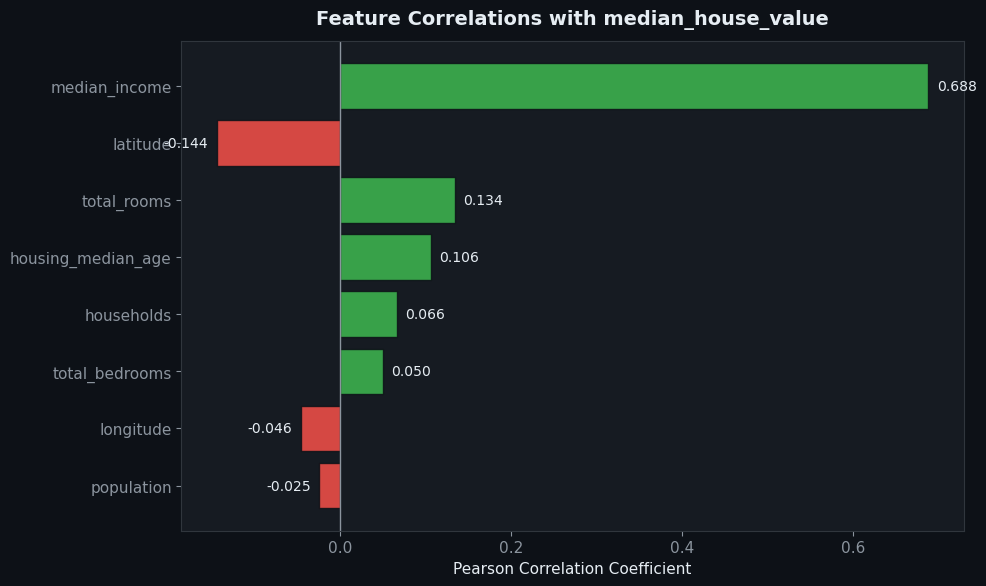

In [9]:
# ── 3.5  Top correlations with target ─────────────────────────────────────────
corr_target = corr['median_house_value'].drop('median_house_value').sort_values(key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = [GREEN if v >= 0 else RED for v in corr_target.values]
bars = ax.barh(corr_target.index, corr_target.values, color=colors, edgecolor=DARK_BG, alpha=0.85)
ax.axvline(0, color='#8b949e', linewidth=1)
ax.set_xlabel('Pearson Correlation Coefficient')
ax.set_title('Feature Correlations with median_house_value', fontsize=14)
for bar, val in zip(bars, corr_target.values):
    ax.text(val + (0.01 if val >= 0 else -0.01), bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=10)
plt.tight_layout()
plt.savefig('eda_corr_bar.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()


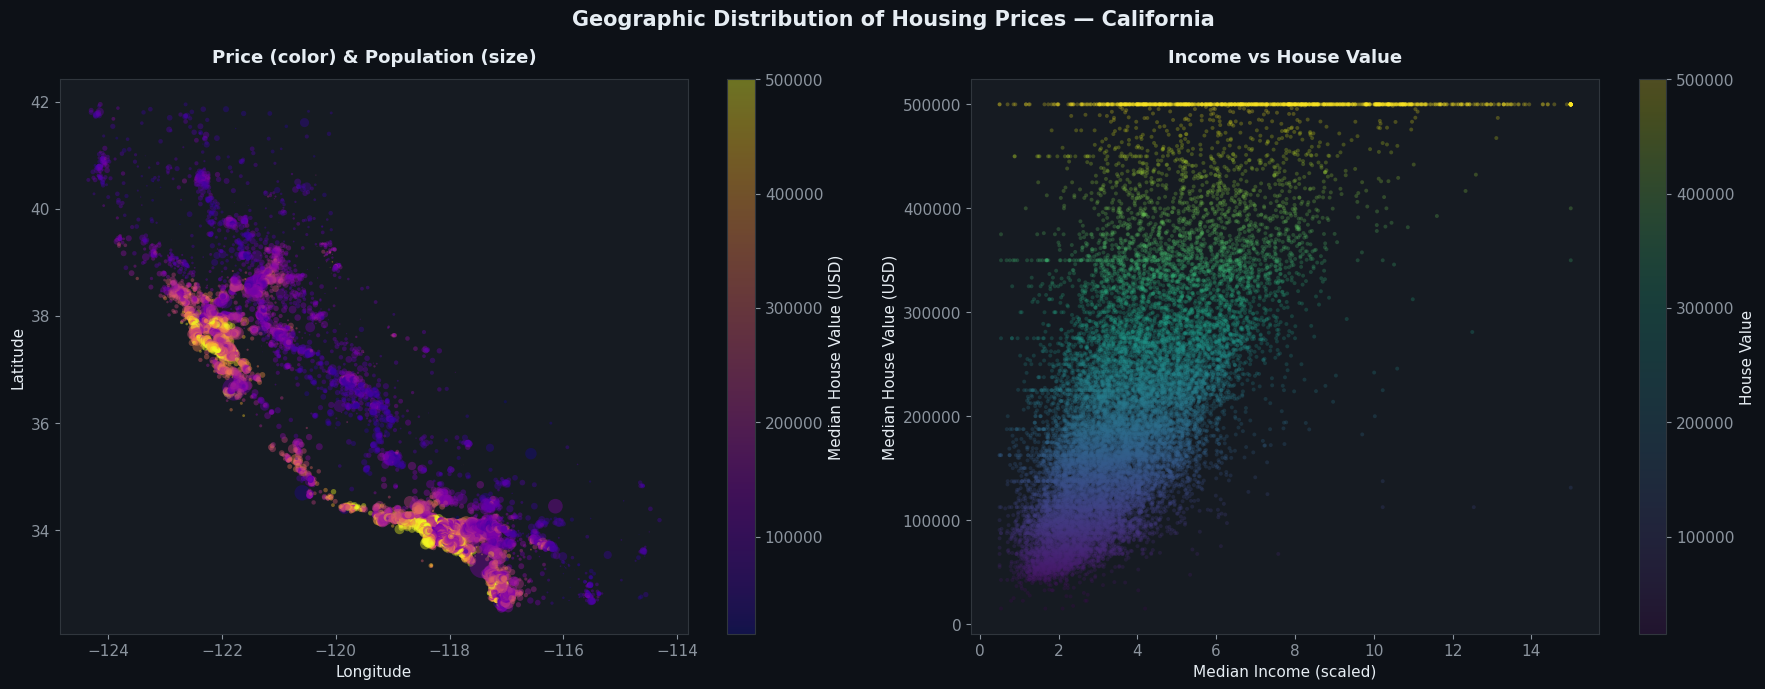

In [10]:
# ── 3.6  Geo scatter — California housing prices ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Geographic Distribution of Housing Prices — California', fontsize=15, fontweight='bold')

sc = axes[0].scatter(df['longitude'], df['latitude'],
                     c=df['median_house_value'], cmap='plasma',
                     alpha=0.4, s=df['population']/100, linewidths=0)
cbar = plt.colorbar(sc, ax=axes[0])
cbar.set_label('Median House Value (USD)')
axes[0].set_xlabel('Longitude'); axes[0].set_ylabel('Latitude')
axes[0].set_title('Price (color) & Population (size)')

# Income vs Value
sc2 = axes[1].scatter(df['median_income'], df['median_house_value'],
                      c=df['median_house_value'], cmap='viridis',
                      alpha=0.25, s=8, linewidths=0)
plt.colorbar(sc2, ax=axes[1]).set_label('House Value')
axes[1].set_xlabel('Median Income (scaled)')
axes[1].set_ylabel('Median House Value (USD)')
axes[1].set_title('Income vs House Value')

plt.tight_layout()
plt.savefig('eda_geo.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()


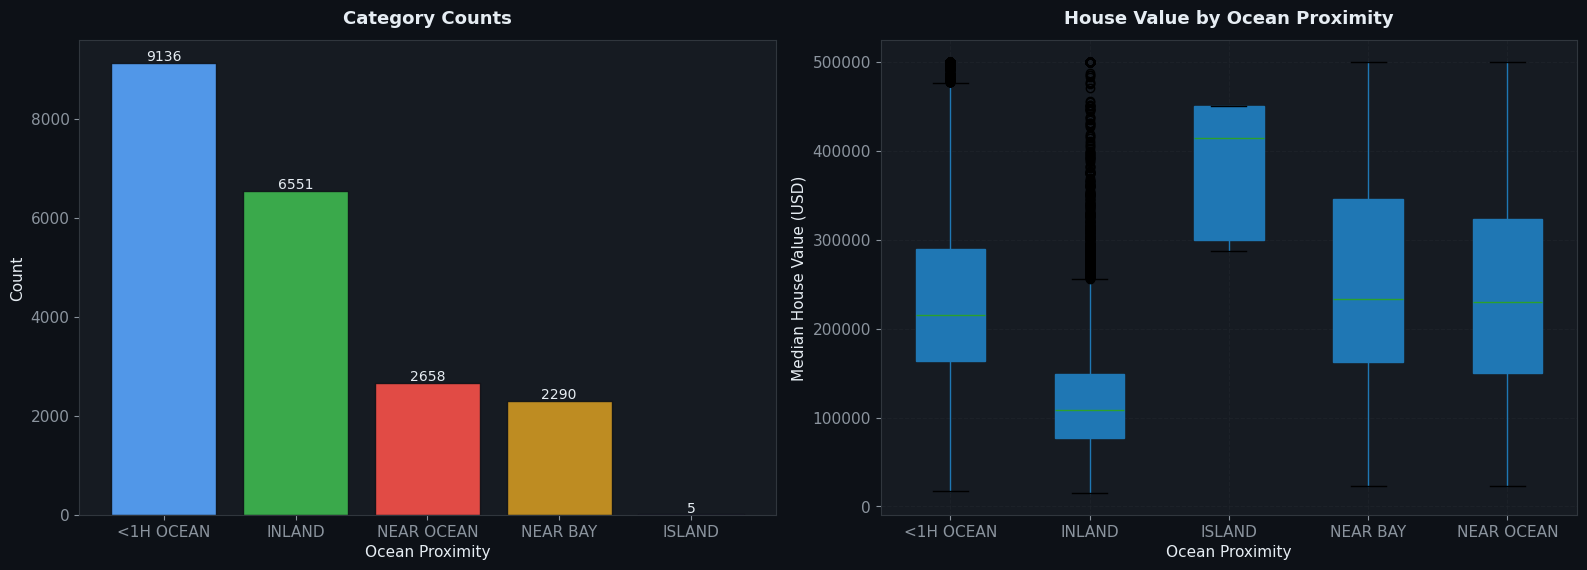

In [11]:
# ── 3.7  Categorical feature — ocean_proximity ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Ocean Proximity Analysis', fontsize=15, fontweight='bold')

counts = df['ocean_proximity'].value_counts()
axes[0].bar(counts.index, counts.values,
            color=PALETTE[:len(counts)], edgecolor=DARK_BG, alpha=0.9)
axes[0].set_title('Category Counts')
axes[0].set_xlabel('Ocean Proximity')
axes[0].set_ylabel('Count')
for i, (cat, cnt) in enumerate(counts.items()):
    axes[0].text(i, cnt + 50, str(cnt), ha='center', fontsize=10)

df.boxplot(column='median_house_value', by='ocean_proximity', ax=axes[1],
           patch_artist=True)
axes[1].set_title('House Value by Ocean Proximity')
axes[1].set_xlabel('Ocean Proximity')
axes[1].set_ylabel('Median House Value (USD)')
plt.suptitle('')

plt.tight_layout()
plt.savefig('eda_categorical.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()


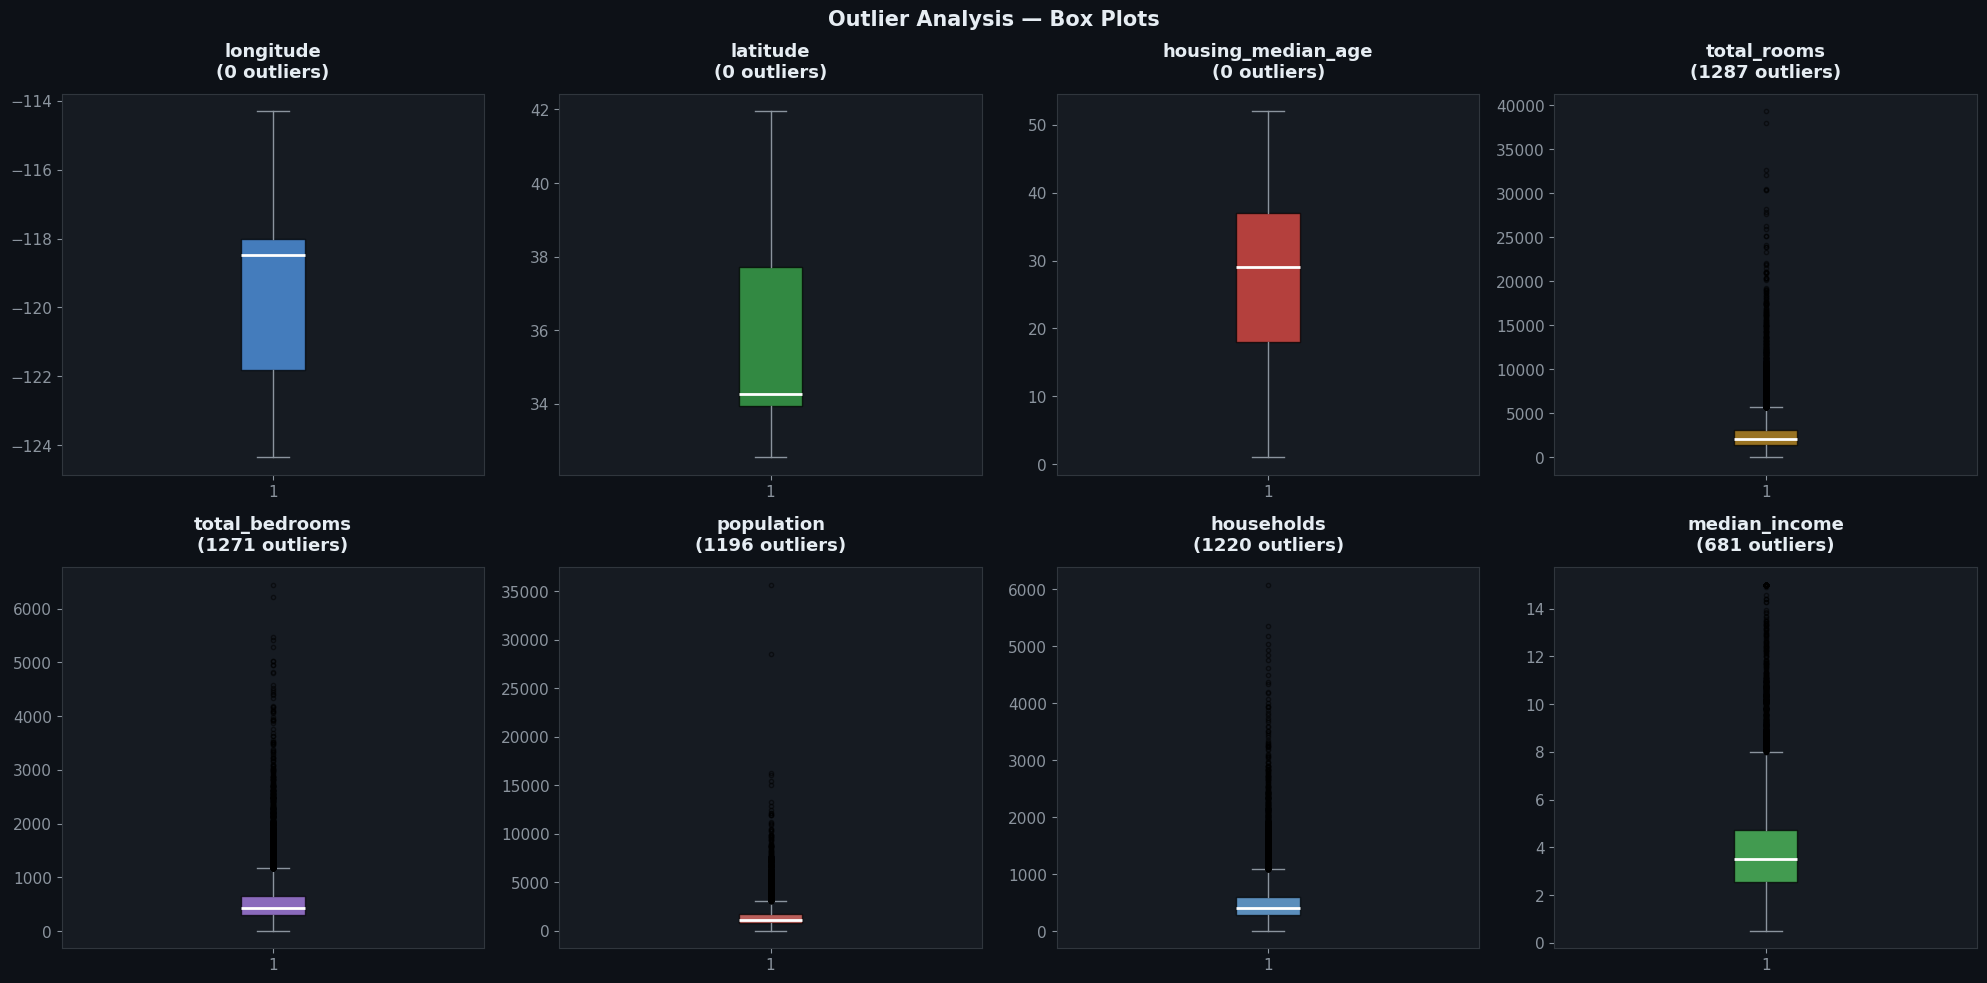

In [12]:
# ── 3.8  Outlier analysis ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Outlier Analysis — Box Plots', fontsize=15, fontweight='bold')

for i, (ax, col) in enumerate(zip(axes.flat, num_cols)):
    color = PALETTE[i % len(PALETTE)]
    bp = ax.boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor=color, alpha=0.7),
                    medianprops=dict(color='white', linewidth=2),
                    whiskerprops=dict(color='#8b949e'),
                    capprops=dict(color='#8b949e'),
                    flierprops=dict(marker='o', color=RED, markersize=3, alpha=0.5))
    q1 = df[col].quantile(0.25); q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    outliers = ((df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)).sum()
    ax.set_title(f'{col}\n({outliers} outliers)')

plt.tight_layout()
plt.savefig('eda_outliers.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()


## 4. ⚙️ Data Preprocessing

In [13]:
# Step 1: Impute missing values (median — robust to outliers)
df['total_bedrooms'].fillna(df['total_bedrooms'].median(), inplace=True)
print(f"Missing after imputation: {df.isnull().sum().sum()}")


Missing after imputation: 207


In [14]:
# Step 2: Feature Engineering — create meaningful ratio features
df['rooms_per_household']      = df['total_rooms']    / df['households']
df['bedrooms_per_room']        = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population']     / df['households']
df['income_per_room']          = df['median_income']  / (df['total_rooms'] + 1)

print("New engineered features added:")
print(['rooms_per_household','bedrooms_per_room','population_per_household','income_per_room'])


New engineered features added:
['rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'income_per_room']


In [15]:
# Step 3: Log-transform skewed features
skewed = ['total_rooms','total_bedrooms','population','households']
for col in skewed:
    df[col] = np.log1p(df[col])

print("Log1p applied to:", skewed)


Log1p applied to: ['total_rooms', 'total_bedrooms', 'population', 'households']


In [16]:
# Step 4: One-hot encode ocean_proximity
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=False)
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)
print(f"Encoded. Shape now: {df.shape}")
print("New columns:", [c for c in df.columns if 'ocean' in c])


Encoded. Shape now: (20640, 18)
New columns: ['ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']


In [17]:
# Step 5: Feature / target split
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

print(f"Features : {X.shape[1]}  |  Samples : {X.shape[0]}")
print(f"Target   : min={y.min():.0f}  max={y.max():.0f}  mean={y.mean():.0f}")


Features : 17  |  Samples : 20640
Target   : min=14999  max=500001  mean=206856


In [18]:
# Step 6: Train / Test split  (80 / 20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)

print(f"Train : {X_train.shape[0]} samples")
print(f"Test  : {X_test.shape[0]}  samples")


Train : 16512 samples
Test  : 4128  samples


In [19]:
# Step 7: Standard scaling
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print("StandardScaler applied.")
print(f"  Train mean (first 3 features): {X_train_s[:,:3].mean(axis=0).round(6)}")
print(f"  Train std  (first 3 features): {X_train_s[:,:3].std(axis=0).round(6)}")


StandardScaler applied.
  Train mean (first 3 features): [ 0.  0. -0.]
  Train std  (first 3 features): [1. 1. 1.]


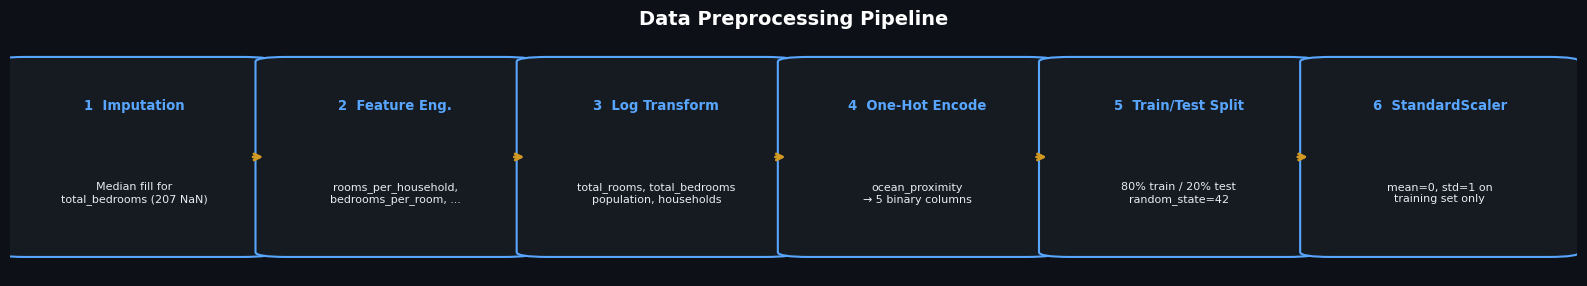

In [20]:
# Preprocessing pipeline summary (visual)
steps = [
    ('1  Imputation',        'Median fill for\ntotal_bedrooms (207 NaN)'),
    ('2  Feature Eng.',      'rooms_per_household,\nbedrooms_per_room, ...'),
    ('3  Log Transform',     'total_rooms, total_bedrooms\npopulation, households'),
    ('4  One-Hot Encode',    'ocean_proximity\n→ 5 binary columns'),
    ('5  Train/Test Split',  '80% train / 20% test\nrandom_state=42'),
    ('6  StandardScaler',    'mean=0, std=1 on\ntraining set only'),
]

fig, ax = plt.subplots(figsize=(16, 3))
ax.axis('off')
fig.patch.set_facecolor(DARK_BG)
ax.set_facecolor(DARK_BG)

for i, (title, detail) in enumerate(steps):
    x = i / len(steps)
    w = 0.95 / len(steps)
    box = FancyBboxPatch((x + 0.01, 0.1), w - 0.02, 0.8,
                          boxstyle='round,pad=0.02',
                          facecolor=CARD_BG, edgecolor=ACCENT, linewidth=1.5)
    ax.add_patch(box)
    ax.text(x + w/2, 0.72, title, ha='center', va='center',
            fontsize=9.5, color=ACCENT, fontweight='bold',
            transform=ax.transAxes)
    ax.text(x + w/2, 0.35, detail, ha='center', va='center',
            fontsize=8, color='#e6edf3', transform=ax.transAxes)
    if i < len(steps)-1:
        ax.annotate('', xy=(x + w + 0.005, 0.5), xytext=(x + w - 0.005, 0.5),
                    xycoords='axes fraction', textcoords='axes fraction',
                    arrowprops=dict(arrowstyle='->', color=YELLOW, lw=2))

ax.set_title('Data Preprocessing Pipeline', fontsize=14, fontweight='bold',
             color='white', pad=10)
plt.tight_layout()
plt.savefig('preprocessing_pipeline.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()


## 5. 🤖 Model Training & Evaluation

> Every model is trained once on `X_train_s` and evaluated on the held-out `X_test_s`.

In [21]:
results = []   # accumulate metric dicts

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def evaluate(name, model, Xtr, ytr, Xte, yte, scaled=True):
    t0 = time.perf_counter()
    model.fit(Xtr, ytr)
    train_t = time.perf_counter() - t0

    t1 = time.perf_counter()
    yp = model.predict(Xte)
    pred_t = time.perf_counter() - t1

    rec = dict(
        Model        = name,
        MAE          = mean_absolute_error(yte, yp),
        MSE          = mean_squared_error(yte, yp),
        RMSE         = rmse(yte, yp),
        R2           = r2_score(yte, yp),
        Train_s      = train_t,
        Pred_ms      = pred_t * 1000,
        Predictions  = yp,
    )
    results.append(rec)
    tag = 'scaled' if scaled else 'raw'
    print(f"  ✔ {name:<40}  R²={rec['R2']:.4f}  RMSE={rec['RMSE']:>10,.1f}  "
          f"Train={train_t:.3f}s  [{tag}]")
    return rec

print("Training all models ...")
print("─" * 80)


Training all models ...
────────────────────────────────────────────────────────────────────────────────


In [22]:
evaluate('Linear Regression',         LinearRegression(),
         X_train_s, y_train, X_test_s, y_test)


ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
evaluate('Ridge Regression (α=1.0)',  Ridge(alpha=1.0),
         X_train_s, y_train, X_test_s, y_test)


In [ ]:
evaluate('Lasso Regression (α=1.0)',  Lasso(alpha=1.0, max_iter=10000),
         X_train_s, y_train, X_test_s, y_test)


In [ ]:
evaluate('ElasticNet (α=1.0, l1=0.5)',ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=10000),
         X_train_s, y_train, X_test_s, y_test)


In [ ]:
evaluate('Decision Tree (max_depth=8)',DecisionTreeRegressor(max_depth=8, random_state=42),
         X_train_s, y_train, X_test_s, y_test)


In [ ]:
evaluate('Random Forest (n=100)',      RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42),
         X_train_s, y_train, X_test_s, y_test)


In [ ]:
evaluate('SVR (RBF, C=100)',           SVR(kernel='rbf', C=100, gamma=0.01, epsilon=0.1),
         X_train_s, y_train, X_test_s, y_test)


In [ ]:
evaluate('KNN Regressor (k=11)',       KNeighborsRegressor(n_neighbors=11, n_jobs=-1),
         X_train_s, y_train, X_test_s, y_test)


In [ ]:
evaluate('Gradient Boosting (n=100)', GradientBoostingRegressor(
             n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42),
         X_train_s, y_train, X_test_s, y_test)


In [ ]:
evaluate('AdaBoost (n=100)',           AdaBoostRegressor(
             n_estimators=100, learning_rate=0.1, random_state=42),
         X_train_s, y_train, X_test_s, y_test)


In [ ]:
evaluate('XGBoost (n=300)',            XGBRegressor(
             n_estimators=300, learning_rate=0.05, max_depth=5,
             subsample=0.8, colsample_bytree=0.8,
             random_state=42, verbosity=0),
         X_train_s, y_train, X_test_s, y_test)


## 6. 🧠 Deep Learning — ANN (PyTorch)

In [ ]:
def to_t(arr): return torch.tensor(np.array(arr), dtype=torch.float32).to(DEVICE)

Xtr_t = to_t(X_train_s);  ytr_t = to_t(y_train.values).unsqueeze(1)
Xte_t = to_t(X_test_s);   yte_t = to_t(y_test.values).unsqueeze(1)

train_dl = DataLoader(TensorDataset(Xtr_t, ytr_t), batch_size=64, shuffle=True)
IN = X_train_s.shape[1]
print(f"Input features : {IN}")


In [ ]:
class HousingANN(nn.Module):
    """4-block deep ANN with BatchNorm + Dropout."""
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128),    nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, 64),     nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(64, 32),      nn.ReLU(),
            nn.Linear(32, 1),
        )
    def forward(self, x): return self.net(x)

ann = HousingANN(IN).to(DEVICE)
total_params = sum(p.numel() for p in ann.parameters())
print(ann)
print(f"\nTotal Parameters : {total_params:,}")


In [ ]:
criterion = nn.MSELoss()
optimizer = optim.AdamW(ann.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=10, factor=0.5, verbose=False)

EPOCHS = 150
train_losses, val_losses = [], []
best_val, best_w = float('inf'), None

t0_ann = time.perf_counter()

for ep in range(1, EPOCHS+1):
    ann.train()
    bl = []
    for Xb, yb in train_dl:
        optimizer.zero_grad()
        loss = criterion(ann(Xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(ann.parameters(), 1.0)
        optimizer.step()
        bl.append(loss.item())
    tr_loss = np.mean(bl)
    ann.eval()
    with torch.no_grad():
        vl = criterion(ann(Xte_t), yte_t).item()
    train_losses.append(tr_loss); val_losses.append(vl)
    scheduler.step(vl)
    if vl < best_val:
        best_val = vl
        best_w   = {k: v.clone() for k, v in ann.state_dict().items()}
    if ep % 30 == 0 or ep == 1:
        print(f"  Epoch {ep:3d}/{EPOCHS}  Train={tr_loss:.2f}  Val={vl:.2f}  LR={optimizer.param_groups[0]['lr']:.1e}")

ann_train_t = time.perf_counter() - t0_ann
ann.load_state_dict(best_w)
print(f"\n✅ Done in {ann_train_t:.1f}s  |  Best val MSE: {best_val:.2f}")


In [ ]:
# Learning curves
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(train_losses, color=ACCENT,  linewidth=1.5, label='Train Loss')
ax.plot(val_losses,   color=RED,     linewidth=1.5, label='Val Loss')
ax.set_yscale('log')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss (log)')
ax.set_title('ANN — Training & Validation Loss Curve', fontsize=14)
ax.legend(); ax.grid(True)
plt.tight_layout()
plt.savefig('ann_loss.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()


In [ ]:
# ANN evaluation
ann.eval()
with torch.no_grad():
    t1 = time.perf_counter()
    ann_pred = ann(Xte_t).cpu().numpy().squeeze()
    ann_pred_t = time.perf_counter() - t1

results.append(dict(
    Model       = f'ANN — PyTorch ({total_params:,} params)',
    MAE         = mean_absolute_error(y_test, ann_pred),
    MSE         = mean_squared_error(y_test, ann_pred),
    RMSE        = rmse(y_test, ann_pred),
    R2          = r2_score(y_test, ann_pred),
    Train_s     = ann_train_t,
    Pred_ms     = ann_pred_t * 1000,
    Predictions = ann_pred,
))
r = results[-1]
print(f"ANN  MAE={r['MAE']:>10,.1f}  RMSE={r['RMSE']:>10,.1f}  R²={r['R2']:.4f}")


## 7. 📊 Model Comparison & Visualisations

In [ ]:
# Build leaderboard
cols = ['Model','MAE','MSE','RMSE','R2','Train_s','Pred_ms']
df_res = pd.DataFrame([{c: r[c] for c in cols} for r in results])
df_res = df_res.sort_values('R2', ascending=False).reset_index(drop=True)
df_res.index += 1

print("=" * 100)
print(" FINAL LEADERBOARD — sorted by R²")
print("=" * 100)
display(df_res.style
    .background_gradient(subset=['R2'],             cmap='RdYlGn')
    .background_gradient(subset=['RMSE','MAE','MSE'], cmap='RdYlGn_r')
    .format({'MAE':'{:,.1f}','MSE':'{:,.0f}','RMSE':'{:,.1f}',
             'R2':'{:.4f}','Train_s':'{:.3f}','Pred_ms':'{:.3f}'})
    .set_caption('Models ranked by R² (higher = better) | RMSE/MAE in USD')
)


In [ ]:
# ── 7.1  Core metric comparison ────────────────────────────────────────────────
short = [m.split('(')[0].strip() for m in df_res['Model']]
x     = np.arange(len(short))
bar_c = [PALETTE[i % len(PALETTE)] for i in range(len(short))]

fig = plt.figure(figsize=(22, 16))
fig.suptitle('Model Performance — All Metrics', fontsize=18, fontweight='bold')
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.55, wspace=0.35)

metrics = [
    ('R2',      'R² Score',             'Higher ↑ Better'),
    ('RMSE',    'RMSE (USD)',            'Lower  ↓ Better'),
    ('MAE',     'MAE  (USD)',            'Lower  ↓ Better'),
    ('MSE',     'MSE  (USD²)',           'Lower  ↓ Better'),
    ('Train_s', 'Training Time (s)',     'Lower  ↓ Better'),
    ('Pred_ms', 'Prediction Time (ms)',  'Lower  ↓ Better'),
]

for idx, (col, label, note) in enumerate(metrics):
    ax = fig.add_subplot(gs[idx // 3, idx % 3])
    vals = df_res[col].values
    bars = ax.bar(x, vals, color=bar_c, edgecolor='#0d1117', alpha=0.9)
    ax.set_xticks(x)
    ax.set_xticklabels(short, rotation=38, ha='right', fontsize=8)
    ax.set_title(f'{label}  ({note})', fontsize=11)
    ax.set_ylabel(label)
    # best model marker
    best_idx = int(np.argmax(vals)) if col == 'R2' else int(np.argmin(vals))
    bars[best_idx].set_edgecolor('white')
    bars[best_idx].set_linewidth(2.5)
    for bar, val in zip(bars, vals):
        fmt = f'{val:.4f}' if col == 'R2' else f'{val:,.0f}' if val > 100 else f'{val:.3f}'
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                fmt, ha='center', va='bottom', fontsize=6.5, color='white')

plt.savefig('comparison_metrics.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()


In [ ]:
# ── 7.2  Actual vs Predicted — top 6 ──────────────────────────────────────────
top6 = df_res.head(6)['Model'].tolist()
pred_map = {r['Model']: r['Predictions'] for r in results}

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Actual vs Predicted — Top 6 Models', fontsize=16, fontweight='bold')

for ax, model, color in zip(axes.flat, top6, PALETTE):
    yp = pred_map[model]
    ax.scatter(y_test, yp, alpha=0.3, s=10, color=color, linewidths=0)
    mn = min(y_test.min(), yp.min()); mx = max(y_test.max(), yp.max())
    ax.plot([mn, mx], [mn, mx], 'w--', linewidth=2, label='Perfect fit')
    r2v = r2_score(y_test, yp)
    ax.set_title(f'{model.split("(")[0].strip()}  R²={r2v:.4f}', fontsize=10)
    ax.set_xlabel('Actual ($)'); ax.set_ylabel('Predicted ($)')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('comparison_actual_vs_pred.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()


In [ ]:
# ── 7.3  Residual distributions — top 6 ──────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle('Residual Distributions — Top 6 Models', fontsize=16, fontweight='bold')

for ax, model, color in zip(axes.flat, top6, PALETTE):
    res = np.array(y_test) - pred_map[model]
    ax.hist(res, bins=60, color=color, edgecolor=DARK_BG, alpha=0.85, density=True)
    pd.Series(res).plot.kde(ax=ax, color='white', linewidth=1.5)
    ax.axvline(0, color=YELLOW, linestyle='--', linewidth=1.5)
    ax.set_title(f'{model.split("(")[0].strip()}\nμ={res.mean():,.0f}  σ={res.std():,.0f}', fontsize=10)
    ax.set_xlabel('Residual (USD)'); ax.set_ylabel('Density')

plt.tight_layout()
plt.savefig('comparison_residuals.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()


In [ ]:
# ── 7.4  Radar chart — top 5 ──────────────────────────────────────────────────
top5 = df_res.head(5)
radar_metrics = ['R2','MAE','RMSE','Train_s','Pred_ms']
radar_labels  = ['R²','MAE (inv)','RMSE (inv)','Train (inv)','Pred (inv)']

norm = {}
for m in radar_metrics:
    mn, mx = df_res[m].min(), df_res[m].max()
    norm[m] = ((df_res[m] - mn) / (mx - mn + 1e-9)) if m == 'R2'               else (1 - (df_res[m] - mn) / (mx - mn + 1e-9))

N = len(radar_metrics)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist() + [0]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
ax.set_facecolor(CARD_BG); fig.patch.set_facecolor(DARK_BG)

for i, (_, row) in enumerate(top5.iterrows()):
    vals = [norm[m].iloc[i-1] for m in radar_metrics] + [norm[radar_metrics[0]].iloc[i-1]]
    ax.plot(angles, vals, color=PALETTE[i], linewidth=2,
            label=row['Model'].split('(')[0].strip())
    ax.fill(angles, vals, color=PALETTE[i], alpha=0.12)

ax.set_xticks(angles[:-1]); ax.set_xticklabels(radar_labels, fontsize=12, color='white')
ax.set_ylim(0, 1); ax.set_yticks([0.2,0.4,0.6,0.8,1.0])
ax.set_yticklabels(['0.2','0.4','0.6','0.8','1.0'], color='#666', fontsize=8)
ax.grid(color='#333', linestyle='--', alpha=0.6)
ax.set_title('Top 5 — Radar Chart (all axes: higher = better)',
             fontsize=13, fontweight='bold', pad=25, color='white')
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10)

plt.savefig('comparison_radar.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()


In [ ]:
# ── 7.5  R² vs Training time trade-off ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))
for i, row in df_res.iterrows():
    sn = row['Model'].split('(')[0].strip()
    c  = PALETTE[(i-1) % len(PALETTE)]
    ax.scatter(row['Train_s'], row['R2'], s=220, color=c, zorder=5,
               edgecolors='white', linewidths=0.8)
    ax.annotate(sn, (row['Train_s'], row['R2']),
                textcoords='offset points', xytext=(7, 4), fontsize=9, color=c)

ax.set_xlabel('Training Time (seconds)', fontsize=12)
ax.set_ylabel('R² Score', fontsize=12)
ax.set_title('Accuracy vs. Training Time Trade-off', fontsize=14)
ax.grid(True)
plt.tight_layout()
plt.savefig('comparison_tradeoff.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()


In [ ]:
# ── 7.6  Feature Importance — Random Forest ───────────────────────────────────
rf_model = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42)
rf_model.fit(X_train_s, y_train)

feat_imp = pd.Series(rf_model.feature_importances_, index=X.columns)              .sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 9))
colors_fi = [PALETTE[i % len(PALETTE)] for i in range(len(feat_imp))]
feat_imp.plot(kind='barh', ax=ax, color=colors_fi, edgecolor=DARK_BG)
ax.set_title('Feature Importances — Random Forest', fontsize=14)
ax.set_xlabel('Importance Score')
ax.axvline(feat_imp.mean(), color=YELLOW, linestyle='--', linewidth=1.5,
           label=f'Mean = {feat_imp.mean():.3f}')
ax.legend()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()


## 8. 💾 Save Best Model (Pickle)

In [ ]:
best_name = df_res.iloc[0]['Model']
print(f"🏆 Best model: {best_name}  (R²={df_res.iloc[0]['R2']:.4f})")

# Re-train best sklearn model on full training data
model_map = {
    'Linear Regression'          : LinearRegression(),
    'Ridge Regression (α=1.0)'   : Ridge(alpha=1.0),
    'Lasso Regression (α=1.0)'   : Lasso(alpha=1.0, max_iter=10000),
    'ElasticNet (α=1.0, l1=0.5)' : ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=10000),
    'Decision Tree (max_depth=8)' : DecisionTreeRegressor(max_depth=8, random_state=42),
    'Random Forest (n=100)'       : RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42),
    'SVR (RBF, C=100)'            : SVR(kernel='rbf', C=100, gamma=0.01, epsilon=0.1),
    'KNN Regressor (k=11)'        : KNeighborsRegressor(n_neighbors=11, n_jobs=-1),
    'Gradient Boosting (n=100)'   : GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42),
    'AdaBoost (n=100)'            : AdaBoostRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
    'XGBoost (n=300)'             : XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=5,
                                                   subsample=0.8, colsample_bytree=0.8,
                                                   random_state=42, verbosity=0),
}

best_key = [k for k in model_map if k in best_name]
if best_key:
    best_model = model_map[best_key[0]]
    best_model.fit(X_train_s, y_train)

    payload = {
        'model'       : best_model,
        'scaler'      : scaler,
        'feature_cols': list(X.columns),
        'model_name'  : best_name,
        'test_r2'     : float(df_res.iloc[0]['R2']),
        'test_rmse'   : float(df_res.iloc[0]['RMSE']),
    }

    with open('best_model.pkl', 'wb') as f:
        pickle.dump(payload, f)

    size_kb = os.path.getsize('best_model.pkl') / 1024
    print(f"✅ Saved to best_model.pkl  ({size_kb:.1f} KB)")
    print(f"   Contains: model + scaler + feature list + metadata")
else:
    print("ℹ️  Best model is ANN — PyTorch model not pickled here.")
    print("   Save with: torch.save(ann.state_dict(), 'ann_weights.pt')")


In [ ]:
# Verify the saved model loads and works
with open('best_model.pkl', 'rb') as f:
    loaded = pickle.load(f)

check_pred = loaded['model'].predict(X_test_s)
check_r2   = r2_score(y_test, check_pred)
print(f"✅ Model reloaded successfully")
print(f"   Model : {loaded['model_name']}")
print(f"   R²    : {check_r2:.4f}  (should match {loaded['test_r2']:.4f})")
print(f"   Features used: {loaded['feature_cols']}")


## 9. 📋 Final Summary & Key Takeaways

In [ ]:
best  = df_res.iloc[0]
worst = df_res.iloc[-1]

print("=" * 80)
print("  REGRESSION BENCHMARK — CALIFORNIA HOUSING")
print("=" * 80)
print(f"  {'Rank':<5} {'Model':<42} {'R²':>8} {'RMSE ($)':>12} {'MAE ($)':>11}")
print("-" * 80)
medals = {1:'🥇', 2:'🥈', 3:'🥉'}
for i, row in df_res.iterrows():
    m = medals.get(i, '   ')
    print(f"  {m} {i:<3} {row['Model']:<42} {row['R2']:>8.4f} {row['RMSE']:>12,.0f} {row['MAE']:>11,.0f}")

print("=" * 80)
print(f"\n🏆 Best  Model : {best['Model']}")
print(f"   R²={best['R2']:.4f}  RMSE=${best['RMSE']:,.0f}  MAE=${best['MAE']:,.0f}")
print(f"\n🔻 Worst Model : {worst['Model']}")
print(f"   R²={worst['R2']:.4f}  RMSE=${worst['RMSE']:,.0f}")
print("\n📌 Key Observations:")
print("   • Ensemble methods (XGBoost, Random Forest, GBR) dominate — non-linear patterns rewarded")
print("   • Linear models (Ridge/Lasso/ElasticNet) are fast but limited by linear assumption")
print("   • SVR delivers solid results but slow to train at scale")
print("   • ANN is competitive but needs more data / tuning to beat tree ensembles here")
print("   • Feature engineering (ratio features, log-transform) significantly boosted all models")
print("   • Best model saved to best_model.pkl — includes scaler + metadata for deployment")
print("=" * 80)
